<a href="https://colab.research.google.com/github/tuhaovan917-ship-it/test_mo_hinh/blob/main/thuc_nghiem_v2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tải bộ dữ liệu, khảo sát dữ liệu

## Tập train

In [1]:
import pandas as pd

# Đường dẫn đến file dữ liệu CSV mới trên Desktop của bạn
new_file_path = "train.csv"

# Đọc file CSV (sử dụng encoding='utf-8' để tránh lỗi đọc tiếng Việt nếu có)
df_new = pd.read_csv(new_file_path, encoding='utf-8')

# 1. Hiển thị tổng số dòng, số cột và kiểu dữ liệu từng cột
print("--- Thông tin bộ dữ liệu Fake-News-Detection ---")
print(df_new.info())

# 2. Hiển thị 5 dòng đầu tiên để xem cấu trúc thực tế
print("\n--- 5 dòng đầu tiên của dữ liệu ---")
df_new.head()

--- Thông tin bộ dữ liệu Fake-News-Detection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8741 entries, 0 to 8740
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_name         8741 non-null   object
 1   post_message      8741 non-null   object
 2   timestamp_post    8741 non-null   object
 3   num_like_post     8741 non-null   object
 4   num_comment_post  8741 non-null   object
 5   num_share_post    8741 non-null   object
 6   label             8741 non-null   int64 
dtypes: int64(1), object(6)
memory usage: 478.2+ KB
None

--- 5 dòng đầu tiên của dữ liệu ---


,user_name,post_message,timestamp_post,num_like_post,num_comment_post,num_share_post,label
0,f3317e52aa79b261db534a38e7f7c360,ĐẾN 18H CHIỀU 10/4 : THÊM 2 CA MẮC COVID-19 ➡️...,1586491781,5505,34,374.0,0
1,cb6ad3159dd0f8cc5fa2833b22ed3c90,Thế giới tuần qua: Nợ công Mỹ tăng kinh hoàng ...,2020-06-13 02:21:21,8.0,2.0,4.0,0
2,0f93c7b7aedee5cd1c69cfa61787d586,Sự_cố đứt cáp AAG không ảnh_hưởng tới chất_lượ...,1585954578,2,0,2.0,0
3,b008022f7508beb6360b691c8c9461e5,TRIỆU CHỨNG NHIỄM CORONA QUA TỪNG NGÀY 🛑Ngày 1...,2020-03-01 18:18:51,1000.0,155.0,3000.0,1
4,92e1c6bf72f2aedf907f4627b67f9e2b,<URL> bị phong tỏa từ ngày 28-3... Phong tỏa 1...,2020-03-26 13:22:00,170.0,15.0,2.0,1


In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")


      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 8741 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 4438 dòng (50.77%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 117 dòng (1.34%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 4293 dòng (49.11%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng bị lỗi khoảng trắng ' _ ']:
  Mặt_trời mọc từ_từ ở phía xa , những tiếng thở_phào nhẽ nhõm thốt lên qua lớp khẩu_trang mỏng : “ Về nhà rồi , an_toàn rồi ” .# doisong # COVID _ 19 # duhọcsinh...

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  Thế giới tuần qua: Nợ công Mỹ tăng kinh hoàng vượt 26.000 tỷ USD, kinh tế Anh sụt giảm kỷ lục
Nợ công Mỹ lần đầu tiên trong lịch sử vượt mốc 26.000 tỷ USD, kinh tế Anh sụt giảm tới 24,5% GDP so với cùng kỳ năm 2019, Brazil bùng nổ số ca nhiễm Cov

In [ ]:
def clean_text_for_phobert(text):
    # 1. Chuyển tất cả dấu gạch dưới về khoảng trắng
    text = str(text).replace('_', ' ')
    # 2. Xóa khoảng trắng thừa (ví dụ: "COVID  19" -> "COVID 19")
    text = " ".join(text.split())
    return text

# Áp dụng cho cột văn bản
df_new['post_message'] = df_new['post_message'].apply(clean_text_for_phobert)

# KIỂM TRA LẠI: Sau khi chạy, nếu con số này bằng 0 thì bạn đã thành công
print("Số lượng dòng còn chứa dấu gạch dưới:", df_new['post_message'].apply(lambda x: '_' in x).sum())

Số lượng dòng còn chứa dấu gạch dưới: 0


In [ ]:
print(df_new['label'].value_counts())

label
0    7269
1    1472
Name: count, dtype: int64


In [ ]:
# In trực tiếp nội dung văn bản thô của dòng đầu tiên (chỉ số 0)
print("--- NỘI DUNG DÒNG 0 ---")
print(df_new['post_message'].iloc[0])

print("\n--- NỘI DUNG DÒNG 1 ---")
print(df_new['post_message'].iloc[1])

--- NỘI DUNG DÒNG 0 ---
ĐẾN 18H CHIỀU 10/4 : THÊM 2 CA MẮC COVID-19 ➡️ BN 256 :Nam , 52 tuổi , quốc tịch Việt Nam , có địa chỉ ở Đình Dù , Văn Lâm , Hưng Yên .Ngày 27/3 , bệnh nhân từ Nga về sân bay Nội Bài trên chuyến bay số hiệu SU 290 .Sau khi nhập cảnh , bệnh nhân được chuyển cách ly tập trung tại Trường Văn hoá Nghệ thuật tỉnh Vĩnh Phúc .Hiện bệnh nhân được cách ly , điều trị tại Bệnh viện Bệnh Nhiệt đới Trung ương cơ sở 2 .➡️ BN 257 :Nữ , 15 tuổi , quốc tịch Việt Nam , trú tại xóm Hội , Hạ Lôi , Mê Linh , Hà Nội .Bệnh nhân là học sinh , đang nghỉ học ở nhà , không đi đâu .Ngày 20/3 , BN243 ( là bạn của bố bệnh nhân ) đến nhà chơi và nói chuyện với bố bệnh nhân .Ngày 8/4 , bệnh nhân có biểu hiện sốt , chảy nước mũi .Ngày 9/4 , bệnh nhân được lấy mẫu xét nghiệm .Ngày 10/4 , xét nghiệm cho kết quả dương tính với virus SARS-CoV -2 .Bố bệnh nhân cũng đã được lấy mẫu xét nghiệm và cho kết quả âm tính .Hiện bệnh nhân đang được cách ly , điều trị tại Bệnh viện Bệnh Nhiệt đới Trung ương c

In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")


      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 8741 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 0 dòng (0.00%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 0 dòng (0.00%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 8741 dòng (100.00%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  ĐẾN 18H CHIỀU 10/4 : THÊM 2 CA MẮC COVID-19 ➡️ BN 256 :Nam , 52 tuổi , quốc tịch Việt Nam , có địa chỉ ở Đình Dù , Văn Lâm , Hưng Yên .Ngày 27/3 , bệnh nhân từ Nga về sân bay Nội Bài trên chuyến bay số hiệu SU 290 .Sau khi nhập cảnh , bệnh nhân được chuyển cách ly tập trung tại Trường Văn hoá Nghệ t...


In [ ]:
# 1. Lọc lấy đúng 2 cột cần thiết và tạo một bản sao độc lập
df_save = df_new[['post_message', 'label']].copy()

# 2. Đổi tên cột sang 'text' và 'labels' đúng theo yêu cầu của bạn
df_save = df_save.rename(columns={
    'post_message': 'text',
    'label': 'labels'
})

# 3. Định nghĩa đường dẫn lưu file (.csv) ra ngoài màn hình Desktop của bạn
# (Hoặc bạn có thể sửa thành './train.csv' nếu muốn lưu ngay trong thư mục code)
save_file_path = "data/train.csv"

# 4. Tiến hành xuất file CSV chuẩn mã hóa tiếng Việt không lo lỗi font
df_save.to_csv(save_file_path, index=False, encoding='utf-8-sig')

print("==================================================")
print("          XUẤT FILE DATA SẠCH THÀNH CÔNG         ")
print("==================================================")
print(f"Đã lưu file tại: {save_file_path}")
print(f"Tổng số dòng đã lưu: {len(df_save)} dòng.")
print("\nXem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:")
print(df_save.head(3))

          XUẤT FILE DATA SẠCH THÀNH CÔNG         
Đã lưu file tại: C:\Users\tuhaovan\Desktop\Project_fake_news\data\train.csv
Tổng số dòng đã lưu: 8741 dòng.

Xem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:
                                                text  labels
0  ĐẾN 18H CHIỀU 10/4 : THÊM 2 CA MẮC COVID-19 ➡️...       0
1  Thế giới tuần qua: Nợ công Mỹ tăng kinh hoàng ...       0
2  Sự cố đứt cáp AAG không ảnh hưởng tới chất lượ...       0


## Tập val

In [ ]:
import pandas as pd

# Đường dẫn đến file dữ liệu CSV mới trên Desktop của bạn
new_file_path = "val.csv"

# Đọc file CSV (sử dụng encoding='utf-8' để tránh lỗi đọc tiếng Việt nếu có)
df_new = pd.read_csv(new_file_path, encoding='utf-8')

# 1. Hiển thị tổng số dòng, số cột và kiểu dữ liệu từng cột
print("--- Thông tin bộ dữ liệu Fake-News-Detection ---")
print(df_new.info())

# 2. Hiển thị 5 dòng đầu tiên để xem cấu trúc thực tế
print("\n--- 5 dòng đầu tiên của dữ liệu ---")
df_new.head()

--- Thông tin bộ dữ liệu Fake-News-Detection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_name         486 non-null    object
 1   post_message      486 non-null    object
 2   timestamp_post    486 non-null    object
 3   num_like_post     486 non-null    object
 4   num_comment_post  486 non-null    object
 5   num_share_post    486 non-null    object
 6   label             486 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 26.7+ KB
None

--- 5 dòng đầu tiên của dữ liệu ---


,user_name,post_message,timestamp_post,num_like_post,num_comment_post,num_share_post,label
0,e923f3b427f2b522dc1fcfa8c2182d64,"Bộ trưởng Bruno Bruins, 56 tuổi, sau đó giải t...",2020-03-19 01:56:14,12.0,0.0,4.0,0
1,99ed0ae1e3149e05968a0b27b4317f1d,"CA BỆNH 266 ( BN 266 ) : Bệnh_nhân nữ , 36 tuổ...",1586838208,1,0,0.0,0
2,-5342659397765167104,"Một cơ_sở y_tế tại Quận Snohomish , Washington...",1970-01-01 00:00:00,5200,280,7900,0
3,-1196254512357159936,TIN NÓNG_HỔI TIN_VUI CHO CẢ NHÀ NHÉ .LÊN CẢ TH...,1581480186.0,6,0,25,1
4,30697acaf31157588779f8cb070a6077,Bế_tắc trong cuộc_sống nên cho con và cháu gái...,1590798000,369,50,7.0,0


In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")


      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 486 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 257 dòng (52.88%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 12 dòng (2.47%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 228 dòng (46.91%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng bị lỗi khoảng trắng ' _ ']:
  " Hãy ngồi yên khi Tổ_quốc cần " .Dù vừa mấy hôm trước , chính họ đã lên_tiếng thoá_mạ bệnh_nhân thứ 17 về việc đi chơi khắp_nơi lây_nhiễm cho nhiều người .Hay cũng mấy hôm trước , họ lên_tiếng mắng_chửi một ông_bầu chân dài từ_chối cách_ly .Nhưng họ vẫn cứ thu_gom đồ_đạc và lên_đường về quê với suy...

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  Bộ trưởng Bruno Bruins, 56 tuổi, sau đó giải thích trên Twitter về sự cố này là do ông đã làm việc quá sức liê

In [ ]:
def clean_text_for_phobert(text):
    # 1. Chuyển tất cả dấu gạch dưới về khoảng trắng
    text = str(text).replace('_', ' ')
    # 2. Xóa khoảng trắng thừa (ví dụ: "COVID  19" -> "COVID 19")
    text = " ".join(text.split())
    return text

# Áp dụng cho cột văn bản
df_new['post_message'] = df_new['post_message'].apply(clean_text_for_phobert)

# KIỂM TRA LẠI: Sau khi chạy, nếu con số này bằng 0 thì bạn đã thành công
print("Số lượng dòng còn chứa dấu gạch dưới:", df_new['post_message'].apply(lambda x: '_' in x).sum())

Số lượng dòng còn chứa dấu gạch dưới: 0


In [ ]:
print(df_new['label'].value_counts())

label
0    404
1     82
Name: count, dtype: int64


In [ ]:
# In trực tiếp nội dung văn bản thô của dòng đầu tiên (chỉ số 0)
print("--- NỘI DUNG DÒNG 0 ---")
print(df_new['post_message'].iloc[0])

print("\n--- NỘI DUNG DÒNG 1 ---")
print(df_new['post_message'].iloc[1])

--- NỘI DUNG DÒNG 0 ---
Bộ trưởng Bruno Bruins, 56 tuổi, sau đó giải thích trên Twitter về sự cố này là do ông đã làm việc quá sức liên tiếp trong những tuần gần đây.

--- NỘI DUNG DÒNG 1 ---
CA BỆNH 266 ( BN 266 ) : Bệnh nhân nữ , 36 tuổi , trú tại Thường Tín , Hà Nội .Ngày 08-10/3 , bệnh nhân đến chăm mẹ tại Khoa Phục hồi chức năng , Bệnh viện Bạch Mai .Ngày 12/3 , bệnh nhân có biểu hiện ngứa họng .Từ ngày 30/3 bệnh nhân cách ly tại nhà .Ngày 12/4 , bệnh nhân được lấy mẫu bệnh phẩm và cho kết quả xét nghiệm dương tính với SARS-CoV -2 vào ngày 14/4 .Hiện bệnh nhân được cách ly , điều trị tại Bệnh viện Bệnh Nhiệt đới Trung ương cơ sở 2 .< URL >


In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")


      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 486 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 0 dòng (0.00%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 0 dòng (0.00%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 486 dòng (100.00%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  Bộ trưởng Bruno Bruins, 56 tuổi, sau đó giải thích trên Twitter về sự cố này là do ông đã làm việc quá sức liên tiếp trong những tuần gần đây....


In [ ]:
# 1. Lọc lấy đúng 2 cột cần thiết và tạo một bản sao độc lập
df_save = df_new[['post_message', 'label']].copy()

# 2. Đổi tên cột sang 'text' và 'labels' đúng theo yêu cầu của bạn
df_save = df_save.rename(columns={
    'post_message': 'text',
    'label': 'labels'
})

# 3. Định nghĩa đường dẫn lưu file (.csv) ra ngoài màn hình Desktop của bạn
# (Hoặc bạn có thể sửa thành './train.csv' nếu muốn lưu ngay trong thư mục code)
save_file_path = "data/val.csv"

# 4. Tiến hành xuất file CSV chuẩn mã hóa tiếng Việt không lo lỗi font
df_save.to_csv(save_file_path, index=False, encoding='utf-8-sig')

print("==================================================")
print("          XUẤT FILE DATA SẠCH THÀNH CÔNG         ")
print("==================================================")
print(f"Đã lưu file tại: {save_file_path}")
print(f"Tổng số dòng đã lưu: {len(df_save)} dòng.")
print("\nXem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:")
print(df_save.head(3))

          XUẤT FILE DATA SẠCH THÀNH CÔNG         
Đã lưu file tại: C:\Users\tuhaovan\Desktop\Project_fake_news\data\val.csv
Tổng số dòng đã lưu: 486 dòng.

Xem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:
                                                text  labels
0  Bộ trưởng Bruno Bruins, 56 tuổi, sau đó giải t...       0
1  CA BỆNH 266 ( BN 266 ) : Bệnh nhân nữ , 36 tuổ...       0
2  Một cơ sở y tế tại Quận Snohomish , Washington...       0


## Tập test

In [ ]:
import pandas as pd

# Đường dẫn đến file dữ liệu CSV mới trên Desktop của bạn
new_file_path = "test.csv"

# Đọc file CSV (sử dụng encoding='utf-8' để tránh lỗi đọc tiếng Việt nếu có)
df_new = pd.read_csv(new_file_path, encoding='utf-8')

# 1. Hiển thị tổng số dòng, số cột và kiểu dữ liệu từng cột
print("--- Thông tin bộ dữ liệu Fake-News-Detection ---")
print(df_new.info())

# 2. Hiển thị 5 dòng đầu tiên để xem cấu trúc thực tế
print("\n--- 5 dòng đầu tiên của dữ liệu ---")
df_new.head()

--- Thông tin bộ dữ liệu Fake-News-Detection ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 486 entries, 0 to 485
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   user_name         486 non-null    object
 1   post_message      486 non-null    object
 2   timestamp_post    486 non-null    object
 3   num_like_post     486 non-null    object
 4   num_comment_post  486 non-null    object
 5   num_share_post    486 non-null    object
 6   label             486 non-null    int64 
dtypes: int64(1), object(6)
memory usage: 26.7+ KB
None

--- 5 dòng đầu tiên của dữ liệu ---


,user_name,post_message,timestamp_post,num_like_post,num_comment_post,num_share_post,label
0,de239d43bc9ca510c642160d93e17932,Vụ Trường quốc_tế Singapore thu 80% học_phí kh...,1589391454,1,0,0.0,0
1,70a149e433119b48d47be21d7952e692,Dự báo thời tiết hôm nay 5/5: Nắng nóng gia tă...,2020-05-04 18:28:23,1.0,0.0,0.0,0
2,-3486512289612838912,Mấy chú Ba Tàu bán bánh bao và mỳ vằn thắn chơ...,2020-04-18 04:16:21,75.0,2.0,7.0,0
3,7bdc76265637bf51dc35eea7fd4b3e86,️🎉 KHAI_TRƯƠNG TUYẾN CÁP VƯỢT BIỂN CÓ TRỤ CÁP ...,1591403727,1980,42,83.0,0
4,9a1c606362ab3ac8796855392570c172,Bannon thẳng_thừng chỉ_trích Trung_Quốc và các...,1588577977.0,72,4,7,1


In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")

      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 486 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 223 dòng (45.88%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 9 dòng (1.85%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 263 dòng (54.12%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng bị lỗi khoảng trắng ' _ ']:
  Bác_sĩ tiết_lộ ' lá_chắn ' cuối_cùng giúp bảo_vệ cơ_thể nếu lỡ nhiễm COVID-19 < URL > Lê_Quốc_Hùng - Trưởng khoa Bệnh Nhiệt_đới , Bệnh_viện Chợ_Rẫy - người trực_tiếp điều_trị thành_công cho hai cha_con người Trung_Quốc mắc COVID-19 tại thành_phố Hồ_Chí_Minh cho rằng , việc súc họng bằng dung_dịch sá...

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  Dự báo thời tiết hôm nay 5/5: Nắng nóng gia tăng ở Bắc Bộ và Trung Bộ, có nơi trên 38 độ C...


In [ ]:
def clean_text_for_phobert(text):
    # 1. Chuyển tất cả dấu gạch dưới về khoảng trắng
    text = str(text).replace('_', ' ')
    # 2. Xóa khoảng trắng thừa (ví dụ: "COVID  19" -> "COVID 19")
    text = " ".join(text.split())
    return text

# Áp dụng cho cột văn bản
df_new['post_message'] = df_new['post_message'].apply(clean_text_for_phobert)

# KIỂM TRA LẠI: Sau khi chạy, nếu con số này bằng 0 thì bạn đã thành công
print("Số lượng dòng còn chứa dấu gạch dưới:", df_new['post_message'].apply(lambda x: '_' in x).sum())

Số lượng dòng còn chứa dấu gạch dưới: 0


In [ ]:
print(df_new['label'].value_counts())

label
0    404
1     82
Name: count, dtype: int64


In [ ]:
# In trực tiếp nội dung văn bản thô của dòng đầu tiên (chỉ số 0)
print("--- NỘI DUNG DÒNG 0 ---")
print(df_new['post_message'].iloc[0])

print("\n--- NỘI DUNG DÒNG 1 ---")
print(df_new['post_message'].iloc[1])

--- NỘI DUNG DÒNG 0 ---
Vụ Trường quốc tế Singapore thu 80% học phí khi dạy online : Không được phép khi chưa thoả thuận được với phụ huynh

--- NỘI DUNG DÒNG 1 ---
Dự báo thời tiết hôm nay 5/5: Nắng nóng gia tăng ở Bắc Bộ và Trung Bộ, có nơi trên 38 độ C


In [ ]:
import pandas as pd
import re

def check_original_segmentation_status(df, text_col="post_message"):
    """
    Hàm kiểm tra xem dữ liệu thô ban đầu đã được tách từ sẵn chưa
    và phát hiện các lỗi định dạng gạch dưới.
    """
    print("==================================================")
    print("      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     ")
    print("==================================================\n")

    total_rows = len(df)

    # 1. Đếm số dòng có chứa từ ghép nối liền chuẩn (ví dụ: từ_ghép)
    # Regex này tìm các chữ cái dính liền với dấu gạch dưới và chữ cái tiếp theo
    standard_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\w+_\w+', str(x)))).sum()

    # 2. Đếm số dòng bị lỗi khoảng trắng xung quanh dấu gạch dưới (ví dụ: luật _ sư)
    corrupted_wseg_count = df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x)))).sum()

    # 3. Đếm số dòng hoàn toàn là văn bản thô (Không chứa bất kỳ dấu gạch dưới nào)
    pure_raw_count = df[text_col].apply(lambda x: '_' not in str(x)).sum()

    # Hiển thị kết quả thống kê mẫu
    print(f"Tổng số dòng trong bộ dữ liệu: {total_rows} dòng\n")
    print(f"1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):")
    print(f"   --> {standard_wseg_count} dòng ({standard_wseg_count/total_rows*100:.2f}%)")

    print(f"\n2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):")
    print(f"   --> {corrupted_wseg_count} dòng ({corrupted_wseg_count/total_rows*100:.2f}%)")

    print(f"\n3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):")
    print(f"   --> {pure_raw_count} dòng ({pure_raw_count/total_rows*100:.2f}%)")

    # --- XEM THỰC TẾ MẪU ---
    print("\n--------------------------------------------------")
    print("XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:")
    print("--------------------------------------------------")

    # Mẫu lỗi khoảng trắng nếu có
    if corrupted_wseg_count > 0:
        print("\n[Mẫu dòng bị lỗi khoảng trắng ' _ ']:")
        sample_corrupted = df[df[text_col].apply(lambda x: bool(re.search(r'\s+_\s+', str(x))))][text_col].head(1).values[0]
        print(f"  {sample_corrupted[:300]}...")

    # Mẫu thuần văn bản thô nếu có
    if pure_raw_count > 0:
        print("\n[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:")
        sample_pure = df[df[text_col].apply(lambda x: '_' not in str(x))][text_col].head(1).values[0]
        print(f"  {sample_pure[:300]}...")

# --- CÁCH CHẠY HÀM KHI VỪA LOAD DỮ LIỆU ---
# Bạn dán câu lệnh này ngay dưới bước load file csv của bạn
check_original_segmentation_status(df_new, text_col="post_message")

      KIỂM TRA CẤU TRÚC ĐỊNH DẠNG TÁCH TỪ GỐC     

Tổng số dòng trong bộ dữ liệu: 486 dòng

1. Số dòng chứa từ ghép nối liền CHUẨN (vd: việt_nam):
   --> 0 dòng (0.00%)

2. Số dòng bị LỖI khoảng trắng quanh dấu gạch dưới (vd: luật _ sư):
   --> 0 dòng (0.00%)

3. Số dòng thuần VĂN BẢN THÔ (Không có dấu gạch dưới nào):
   --> 486 dòng (100.00%)

--------------------------------------------------
XEM MẪU THỰC TẾ TRONG BỘ DỮ LIỆU:
--------------------------------------------------

[Mẫu dòng thuần văn bản thô - Không có dấu gạch dưới]:
  Vụ Trường quốc tế Singapore thu 80% học phí khi dạy online : Không được phép khi chưa thoả thuận được với phụ huynh...


In [ ]:
# 1. Lọc lấy đúng 2 cột cần thiết và tạo một bản sao độc lập
df_save = df_new[['post_message', 'label']].copy()

# 2. Đổi tên cột sang 'text' và 'labels' đúng theo yêu cầu của bạn
df_save = df_save.rename(columns={
    'post_message': 'text',
    'label': 'labels'
})

# 3. Định nghĩa đường dẫn lưu file (.csv) ra ngoài màn hình Desktop của bạn
# (Hoặc bạn có thể sửa thành './train.csv' nếu muốn lưu ngay trong thư mục code)
save_file_path = "data/test.csv"

# 4. Tiến hành xuất file CSV chuẩn mã hóa tiếng Việt không lo lỗi font
df_save.to_csv(save_file_path, index=False, encoding='utf-8-sig')

print("==================================================")
print("          XUẤT FILE DATA SẠCH THÀNH CÔNG         ")
print("==================================================")
print(f"Đã lưu file tại: {save_file_path}")
print(f"Tổng số dòng đã lưu: {len(df_save)} dòng.")
print("\nXem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:")
print(df_save.head(3))

          XUẤT FILE DATA SẠCH THÀNH CÔNG         
Đã lưu file tại: C:\Users\tuhaovan\Desktop\Project_fake_news\data\test.csv
Tổng số dòng đã lưu: 486 dòng.

Xem cấu trúc 3 dòng đầu tiên trong file sẽ lưu:
                                                text  labels
0  Vụ Trường quốc tế Singapore thu 80% học phí kh...       0
1  Dự báo thời tiết hôm nay 5/5: Nắng nóng gia tă...       0
2  Mấy chú Ba Tàu bán bánh bao và mỳ vằn thắn chơ...       0


# Khảo sát dữ liệu

In [ ]:
import pandas as pd
import os

# Đường dẫn đến thư mục chứa dữ liệu của bạn
data_dir = "data"

# Định nghĩa tên các file (bạn kiểm tra xem tên file có chính xác không nhé)
files = {
    "Train": "train.csv",
    "Validation": "val.csv",
    "Test": "test.csv"
}

print(f"{'Tập dữ liệu':<15} | {'Số lượng mẫu':<15}")
print("-" * 35)

total_count = 0
for name, filename in files.items():
    path = os.path.join(data_dir, filename)
    if os.path.exists(path):
        df = pd.read_csv(path)
        count = len(df)
        total_count += count
        print(f"{name:<15} | {count:<15}")
    else:
        print(f"{name:<15} | Không tìm thấy file")

print("-" * 35)
print(f"{'Tổng cộng':<15} | {total_count:<15}")

Tập dữ liệu     | Số lượng mẫu   
-----------------------------------
Train           | 8741           
Validation      | 486            
Test            | 486            
-----------------------------------
Tổng cộng       | 9713           


In [ ]:
import pandas as pd
import os

# Định nghĩa đường dẫn chứa các file
data_dir = "data"
file_names = ['train.csv', 'val.csv', 'test.csv']

print(f"{'Tên file':<15} | {'Tổng dòng':<10} | {'Tin Thật (0)':<12} | {'Tin Giả (1)':<12} | {'Độ dài trung bình'}")
print("-" * 80)

for file in file_names:
    path = os.path.join(data_dir, file)

    if os.path.exists(path):
        df = pd.read_csv(path)

        # Tính toán thống kê
        total = len(df)
        label_0 = (df['labels'] == 0).sum()
        label_1 = (df['labels'] == 1).sum()

        # Tính độ dài trung bình (số từ)
        df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
        avg_len = df['word_count'].mean()

        print(f"{file:<15} | {total:<10} | {label_0:<12} | {label_1:<12} | {avg_len:.2f} từ")
    else:
        print(f"{file:<15} | Không tìm thấy file!")

print("\n--- Ghi chú ---")
print("1. Nếu 'Tin Giả' quá ít so với 'Tin Thật', bạn cần tăng cường (Augmentation) như đã làm.")
print("2. Nếu độ dài trung bình > 256 từ, chiến thuật 'Cửa sổ trượt' (Sliding Window) là cần thiết.")

Tên file        | Tổng dòng  | Tin Thật (0) | Tin Giả (1)  | Độ dài trung bình
--------------------------------------------------------------------------------
train.csv       | 8741       | 7269         | 1472         | 170.75 từ
val.csv         | 486        | 404          | 82           | 196.28 từ
test.csv        | 486        | 404          | 82           | 181.63 từ

--- Ghi chú ---
1. Nếu 'Tin Giả' quá ít so với 'Tin Thật', bạn cần tăng cường (Augmentation) như đã làm.
2. Nếu độ dài trung bình > 256 từ, chiến thuật 'Cửa sổ trượt' (Sliding Window) là cần thiết.


In [ ]:
import pandas as pd
import os

# 1. Đọc dữ liệu từ các tệp hiện có
df_train = pd.read_csv("train.csv")
df_val = pd.read_csv("val.csv")
df_test = pd.read_csv("test.csv")

# 2. Gộp để lấy tổng số lượng mẫu (chỉ để tính toán tỉ lệ)
# Chúng ta không thay đổi nội dung file gốc, chỉ dùng để tính toán
total_df = pd.concat([df_train, df_val, df_test], ignore_index=True)
total_count = len(total_df)

# Tính số lượng mong muốn cho tỉ lệ 8:1:1
n_train = int(total_count * 0.8)
n_val = int(total_count * 0.1)
# n_test là phần còn lại

# 3. Xáo trộn toàn bộ dữ liệu
shuffled_df = total_df.sample(frac=1, random_state=42).reset_index(drop=True)

# 4. Cắt theo tỉ lệ đã tính
df_train_new = shuffled_df.iloc[:n_train]
df_val_new = shuffled_df.iloc[n_train : n_train + n_val]
df_test_new = shuffled_df.iloc[n_train + n_val:]

# 5. Ghi đè trực tiếp vào các file cũ
df_train_new.to_csv("train.csv", index=False, encoding='utf-8-sig')
df_val_new.to_csv("val.csv", index=False, encoding='utf-8-sig')
df_test_new.to_csv("test.csv", index=False, encoding='utf-8-sig')

# 6. Thống kê lại
print(f"Tổng số mẫu: {total_count}")
print(f"Đã chia lại: Train={len(df_train_new)}, Val={len(df_val_new)}, Test={len(df_test_new)}")

In [ ]:
!pip install tqdm sacremoses

In [ ]:
import pandas as pd
import torch
from transformers import MarianMTModel, MarianTokenizer
from tqdm import tqdm

# 1. Cấu hình thiết bị
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Đang sử dụng thiết bị: {device}")

# 2. Nạp dữ liệu
file_path = "data/train.csv"
df_save = pd.read_csv(file_path)
fake_news = df_save[df_save['labels'] == 1].copy()

# Lọc câu quá ngắn (để tránh lỗi dịch thuật)
texts_to_translate = [str(t) for t in fake_news['text'] if len(str(t).split()) > 5]
print(f"Tổng tin giả cần dịch: {len(texts_to_translate)}")

# 3. Load model (tải sẵn lên GPU)
print("Đang load mô hình dịch thuật, vui lòng chờ...")
model_name_vi_en = "Helsinki-NLP/opus-mt-vi-en"
model_name_en_vi = "Helsinki-NLP/opus-mt-en-vi"

tokenizer_vi_en = MarianTokenizer.from_pretrained(model_name_vi_en)
model_vi_en = MarianMTModel.from_pretrained(model_name_vi_en).to(device)
tokenizer_en_vi = MarianTokenizer.from_pretrained(model_name_en_vi)
model_en_vi = MarianMTModel.from_pretrained(model_name_en_vi).to(device)

def back_translate_batch(texts, batch_size=16): # Giảm batch_size xuống 8 nếu bị thiếu bộ nhớ (OOM)
    results = []
    # Dùng tqdm để hiển thị thanh tiến trình
    total_batches = (len(texts) + batch_size - 1) // batch_size

    for i in tqdm(range(0, len(texts), batch_size), total=total_batches, desc="Đang dịch Back-Translation"):
        batch = texts[i : i + batch_size]

        # VI -> EN
        inputs_en = tokenizer_vi_en(batch, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            translated_en = model_vi_en.generate(**inputs_en, max_length=512)
        text_en = tokenizer_vi_en.batch_decode(translated_en, skip_special_tokens=True)

        # EN -> VI
        inputs_vi = tokenizer_en_vi(text_en, return_tensors="pt", padding=True, truncation=True, max_length=512).to(device)
        with torch.no_grad():
            translated_vi = model_en_vi.generate(**inputs_vi, max_length=512)
        text_vi = tokenizer_en_vi.batch_decode(translated_vi, skip_special_tokens=True)

        results.extend(text_vi)

        # Giải phóng bộ nhớ GPU sau mỗi batch
        torch.cuda.empty_cache()

    return results

# 4. Thực hiện dịch
print("Bắt đầu dịch...")
augmented_texts = back_translate_batch(texts_to_translate, batch_size=8)

# 5. Lưu kết quả
augmented_df = pd.DataFrame({'text': augmented_texts, 'labels': 1})
df_augmented = pd.concat([df_save, augmented_df], ignore_index=True)

save_file_path = "data/train.csv"
df_augmented.to_csv(save_file_path, index=False, encoding='utf-8-sig')

print(f"\n==================================================")
print(f"XONG! Đã tăng cường thêm: {len(augmented_texts)} mẫu.")
print(f"Đã lưu tại: {save_file_path}")
print(f"==================================================")

In [ ]:
import pandas as pd
import os

data_dir = "data"
# Lưu ý: Mình dùng tên file gốc của bạn, nếu bạn đã tạo file 'segmented_'
# thì hãy đổi tên file trong list này nhé.
files = ['train.csv', 'val.csv', 'test.csv']
WORD_LIMIT = 200

print(f"{'Tên file':<15} | {'Nhãn':<8} | {'Tổng':<10} | {'Vượt ngưỡng':<12} | {'Tỉ lệ vượt'}")
print("-" * 75)

for file in files:
    path = os.path.join(data_dir, file)
    if os.path.exists(path):
        df = pd.read_csv(path)
        df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))

        # Duyệt qua từng nhãn
        for label in [0, 1]:
            subset = df[df['labels'] == label]
            total_label = len(subset)
            long_label = (subset['word_count'] > WORD_LIMIT).sum()
            ratio = (long_label / total_label * 100) if total_label > 0 else 0

            label_name = "Tin Thật" if label == 0 else "Tin Giả"
            print(f"{file:<15} | {label_name:<8} | {total_label:<10} | {long_label:<12} | {ratio:.2f}%")
        print("-" * 75)
    else:
        print(f"{file:<15} | Không tìm thấy!")

Tên file        | Nhãn     | Tổng       | Vượt ngưỡng  | Tỉ lệ vượt
---------------------------------------------------------------------------
train.csv       | Tin Thật | 7269       | 1552         | 21.35%
train.csv       | Tin Giả  | 1472       | 367          | 24.93%
---------------------------------------------------------------------------
val.csv         | Tin Thật | 404        | 92           | 22.77%
val.csv         | Tin Giả  | 82         | 26           | 31.71%
---------------------------------------------------------------------------
test.csv        | Tin Thật | 404        | 98           | 24.26%
test.csv        | Tin Giả  | 82         | 22           | 26.83%
---------------------------------------------------------------------------


In [ ]:
import zipfile
import os

# Đường dẫn đến file zip của bạn
zip_file_path = 'vncorenlp_models.zip'
# Thư mục đích muốn giải nén ra
extract_to = 'vncorenlp_models'

# Kiểm tra xem file có tồn tại không
if os.path.exists(zip_file_path):
    with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Đã giải nén thành công vào thư mục: {extract_to}")

    # Kiểm tra xem các file đã giải nén có nằm đúng chỗ không
    print("Danh sách các file đã giải nén:")
    print(os.listdir(extract_to))
else:
    print(f"Không tìm thấy file {zip_file_path}. Vui lòng kiểm tra lại tên file!")

In [ ]:
import pandas as pd
import os
import re
from tqdm import tqdm
from vncorenlp import VnCoreNLP

# 1. Cấu hình VnCoreNLP
# Đảm bảo bạn đã giải nén thư mục 'vncorenlp_models' vào thư mục gốc của Colab
jar_path = os.path.abspath("./vncorenlp_models/VnCoreNLP-1.2.jar")
rdrsegmenter = VnCoreNLP(jar_path, annotators="wseg", max_heap_size='-Xmx2g')

# Hàm làm sạch
def clean_text(text):
    text = str(text)
    # Xóa URL
    text = re.sub(r'http\S+|www\S+', ' ', text, flags=re.IGNORECASE)
    # Giữ lại chữ cái, số, dấu câu cơ bản. Xóa ký tự lạ
    text = re.sub(r'[^\w\s\.\,\?\!]', ' ', text, flags=re.UNICODE)
    # Xóa khoảng trắng thừa
    text = re.sub(r'\s+', ' ', text, flags=re.UNICODE).strip()
    return text

# Hàm tách từ chuẩn PhoBERT (Sử dụng word_segment để tự động thêm '_')
def segment_text(text):
    # word_segment trả về chuỗi đã tách từ với dấu gạch dưới cho từ ghép
    return rdrsegmenter.word_segment(text)

# 2. Quy trình xử lý
data_dir = "data"
file_names = ['train.csv', 'val.csv', 'test.csv']

for file_name in file_names:
    input_path = os.path.join(data_dir, file_name)
    output_path = os.path.join(data_dir, f"segmented_{file_name}")

    if os.path.exists(input_path):
        print(f"--- Đang xử lý: {file_name} ---")
        df = pd.read_csv(input_path)

        tqdm.pandas()
        # Bước 1: Làm sạch
        df['text'] = df['text'].progress_apply(clean_text)

        # Bước 2: Tách từ (đã dùng word_segment để có dấu '_')
        df['text'] = df['text'].progress_apply(segment_text)

        # Loại bỏ các dòng trống sau khi xử lý
        df = df[df['text'].str.strip() != ""]

        # Lưu file
        df.to_csv(output_path, index=False, encoding='utf-8-sig')
        print(f"Đã lưu file: {output_path}")
    else:
        print(f"Không tìm thấy file: {input_path}")

--- Đang xử lý: train.csv ---


100%|██████████| 8741/8741 [00:00<00:00, 115094.80it/s]


Đã lưu file: C:\Users\tuhaovan\Desktop\Project_fake_news\data\segmented_train.csv
--- Đang xử lý: val.csv ---


100%|██████████| 486/486 [00:00<00:00, 119780.92it/s]


Đã lưu file: C:\Users\tuhaovan\Desktop\Project_fake_news\data\segmented_val.csv
--- Đang xử lý: test.csv ---


100%|██████████| 486/486 [00:00<00:00, 109522.44it/s]

Đã lưu file: C:\Users\tuhaovan\Desktop\Project_fake_news\data\segmented_test.csv


In [ ]:
import pandas as pd
import os

data_dir = "data"
segmented_files = ['segmented_train.csv', 'segmented_val.csv', 'segmented_test.csv']

print(f"{'Tên file':<25} | {'Số dòng':<10} | {'Độ dài TB (từ)'}")
print("-" * 55)

for file_name in segmented_files:
    path = os.path.join(data_dir, file_name)
    if os.path.exists(path):
        df = pd.read_csv(path)

        # Kiểm tra xem có dòng nào bị trống text không
        empty_rows = df['text'].isnull().sum()

        # Thống kê độ dài
        df['word_count'] = df['text'].apply(lambda x: len(str(x).split()))
        avg_len = df['word_count'].mean()

        print(f"{file_name:<25} | {len(df):<10} | {avg_len:.2f}")

        # Xem thử 1 mẫu để check định dạng tách từ
        print(f"   -> Mẫu text: {df['text'].iloc[0][:60]}...")
        if empty_rows > 0:
            print(f"   !!! Cảnh báo: Có {empty_rows} dòng bị trống!")
    else:
        print(f"{file_name:<25} | Không tìm thấy!")

print("-" * 55)
print("Kiểm tra hoàn tất. Nếu số lượng dòng ổn và mẫu text có dấu '_' là bạn đã sẵn sàng!")

Tên file                  | Số dòng    | Độ dài TB (từ)
-------------------------------------------------------
segmented_train.csv       | 8721       | 79.45
   -> Mẫu text: ĐẾN 18H CHIỀU 10 4 THÊM 2 CA MẮC COVID 19 BN 256 Nam , 52 tu...
segmented_val.csv         | 486        | 81.83
   -> Mẫu text: Bộ_trưởng Bruno_Bruins , 56 tuổi , sau đó giải_thích trên Tw...
segmented_test.csv        | 486        | 82.40
   -> Mẫu text: Vụ Trường quốc_tế Singapore thu 80 học_phí khi dạy online Kh...
-------------------------------------------------------
Kiểm tra hoàn tất. Nếu số lượng dòng ổn và mẫu text có dấu '_' là bạn đã sẵn sàng!


# Mô hình

In [ ]:
import random
import torch
import pandas as pd
from torch.utils.data import Dataset

class FakeNewsDataset(Dataset):
    def __init__(self, data, tokenizer, max_len=256, mode='train', limit=200):
        if isinstance(data, str):
            self.df = pd.read_csv(data)
        else:
            self.df = data

        self.tokenizer = tokenizer
        self.max_len = max_len
        self.mode = mode
        self.limit = limit # Cho phép chỉnh limit bên ngoài

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        text = str(self.df.loc[idx, 'text'])
        label = self.df.loc[idx, 'labels']

        # Chế độ 'train' dùng Random Chunking
        if self.mode == 'train':
            words = text.split()
            if len(words) > self.limit:
                start_idx = random.randint(0, len(words) - self.limit)
                text = " ".join(words[start_idx : start_idx + self.limit])

        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_len,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )

        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'labels': torch.tensor(label, dtype=torch.long)
        }

In [ ]:
import torch
import torch.nn as nn
import pandas as pd

# 1. Khởi tạo thiết bị (Ưu tiên GPU/CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Mô hình đang chạy trên thiết bị: {device}")

# 2. Đọc dữ liệu tập train để tính trọng số
# Lưu ý: Đảm bảo đường dẫn file chính xác
train_df = pd.read_csv("data/segmented_train.csv")

# 3. Tính toán số lượng nhãn
n_real = (train_df['labels'] == 0).sum()
n_fake = (train_df['labels'] == 1).sum()
total_samples = len(train_df)
num_classes = 2

# 4. Tính toán trọng số lớp (class weights) theo công thức chuẩn hóa
# Công thức: w_i = Total / (Num_classes * n_i)
# Điều này giúp cân bằng đóng góp của mỗi lớp vào hàm loss tổng thể
weight_0 = total_samples / (num_classes * n_real)
weight_1 = total_samples / (num_classes * n_fake)

class_weights = torch.tensor([weight_0, weight_1], dtype=torch.float).to(device)

# 5. Khai báo hàm mất mát (Loss Function)
# CrossEntropyLoss với trọng số class_weights giúp giảm thiên kiến (bias) vào lớp đa số
criterion = nn.CrossEntropyLoss(weight=class_weights)

print(f"Số lượng nhãn 0 (Real): {n_real}")
print(f"Số lượng nhãn 1 (Fake): {n_fake}")
print(f"Tổng số mẫu: {total_samples}")
print(f"Trọng số áp dụng (weights): {class_weights.tolist()}")

Mô hình đang chạy trên thiết bị: cuda
Số lượng nhãn 0: 7249
Số lượng nhãn 1: 1472
Trọng số áp dụng (weights): [1.0, 4.9245924949646]


In [ ]:
# Xem độ dài câu
df_train = pd.read_csv("data/segmented_train.csv")
# Đếm số từ trong mỗi câu
lengths = df_train['text'].apply(lambda x: len(str(x).split()))

print(f"Độ dài trung bình: {lengths.mean():.2f} từ")
print(f"Độ dài tối đa: {lengths.max()} từ")
print(f"Độ dài tại mốc 95%: {lengths.quantile(0.95)} từ")

Độ dài trung bình: 79.45 từ
Độ dài tối đa: 200 từ
Độ dài tại mốc 95%: 200.0 từ


In [ ]:
from transformers import AutoModelForSequenceClassification

# 1. Khởi tạo mô hình thuần PhoBERT cho bài toán phân loại
# Dùng phobert-base-v2 (phiên bản mới nhất và tốt nhất của VinAI)
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base-v2",
    num_labels=2
)

# Chuyển mô hình sang GPU
model = model.to(device)

print("Đã khởi tạo xong mô hình thuần PhoBERT cho phân loại 2 nhãn.")

config.json:   0%|          | 0.00/678 [00:00<?, ?B/s]

pytorch_model.bin:   0%|          | 0.00/540M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Đã khởi tạo xong mô hình thuần PhoBERT cho phân loại 2 nhãn.


model.safetensors:   0%|          | 0.00/540M [00:00<?, ?B/s]

# Huấn luyện mô hình

In [ ]:
import torch
from sklearn.metrics import f1_score
from tqdm import tqdm # Đừng quên import tqdm để theo dõi tiến trình

def train_model(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    correct = 0

    for batch in loader:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)
        correct += (predicted == labels).sum().item()

    return total_loss / len(loader), correct / len(loader.dataset)

def sliding_window(text, window_size=200, overlap=50):
    words = text.split()
    segments = []
    step = window_size - overlap
    for i in range(0, len(words), step):
        segment = " ".join(words[i : i + window_size])
        segments.append(segment)
        if i + window_size >= len(words): break
    return segments

def predict_single_text(raw_text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        raw_text,
        add_special_tokens=True,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, predicted = torch.max(outputs.logits, 1)

    return predicted.item()

def predict_long_text_sliding_window(raw_text, model, tokenizer, device, window_size=200, overlap=50):
    words = raw_text.split()
    if len(words) <= window_size:
        return predict_single_text(raw_text, model, tokenizer, device)

    segments = sliding_window(raw_text, window_size, overlap)
    votes = [predict_single_text(seg, model, tokenizer, device) for seg in segments]
    return 1 if sum(votes) / len(votes) > 0.5 else 0

def evaluate_with_sliding_window(df_val, model, tokenizer, device):
    model.eval()
    all_preds = []
    all_labels = df_val['labels'].tolist()

    with torch.no_grad():
        # Dùng tqdm để bạn biết quá trình đánh giá đang chạy đến đâu
        for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Evaluating"):
            pred = predict_long_text_sliding_window(str(row['text']), model, tokenizer, device)
            all_preds.append(pred)

    f1 = f1_score(all_labels, all_preds, average='binary')
    return 0.0, f1 # Trả về 0.0 cho loss vì sliding window không dùng loss chuẩn của batch

In [ ]:
from torch.utils.data import DataLoader
from transformers import AutoTokenizer

# Sửa lại dòng này để dùng tokenizer an toàn hơn
tokenizer = AutoTokenizer.from_pretrained("vinai/phobert-base-v2", use_fast=False)

# Tạo lại các tập dữ liệu với tokenizer mới
train_ds = FakeNewsDataset("data/segmented_train.csv", tokenizer)
val_ds = FakeNewsDataset("data/segmented_val.csv", tokenizer)

# Tạo DataLoader
train_loader = DataLoader(train_ds, batch_size=16, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=16)

print("Đã khởi tạo xong DataLoader!")

Đã khởi tạo xong DataLoader!


In [ ]:
import torch
import torch.optim as optim
from tqdm import tqdm
from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt

# 1. Khởi tạo mô hình
model = AutoModelForSequenceClassification.from_pretrained(
    "vinai/phobert-base-v2",
    num_labels=2
).to(device)

# 2. Optimizer và Criterion
optimizer = optim.AdamW(model.parameters(), lr=2e-5)
criterion = torch.nn.CrossEntropyLoss(weight=class_weights.to(device))

epochs = 15
best_f1 = 0.0
best_loss = float('inf')

save_path_f1 = "best_model_f1.pth"
save_path_loss = "best_model_loss.pth"

val_df = pd.read_csv("data/segmented_val.csv")

history = {
    'train_loss': [], 'train_acc': [], 'train_f1': [],
    'val_loss': [], 'val_acc': [], 'val_f1': []
}

print("--- BẮT ĐẦU HUẤN LUYỆN ---")

for epoch in range(epochs):
    # --- HUẤN LUYỆN ---
    model.train()
    total_train_loss = 0
    all_train_preds = []
    all_train_labels = []

    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=True)
    for batch in loop:
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        labels = batch['labels'].to(device)

        optimizer.zero_grad()
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        loss = criterion(outputs.logits, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()
        _, predicted = torch.max(outputs.logits, 1)

        all_train_preds.extend(predicted.cpu().numpy())
        all_train_labels.extend(labels.cpu().numpy())
        loop.set_postfix(loss=loss.item())

    avg_train_loss = total_train_loss / len(train_loader)
    train_acc = accuracy_score(all_train_labels, all_train_preds)
    train_f1 = f1_score(all_train_labels, all_train_preds, average='binary')

    # --- ĐÁNH GIÁ VỚI SLIDING WINDOW ---
    # sliding window không tính loss chuẩn của batch, ta dùng 0.0 hoặc tính xấp xỉ
    val_loss, val_f1 = evaluate_with_sliding_window(val_df, model, tokenizer, device)

    # Tính accuracy cho sliding window
    all_val_preds = []
    all_val_labels = val_df['labels'].tolist()
    for _, row in val_df.iterrows():
        all_val_preds.append(predict_long_text_sliding_window(str(row['text']), model, tokenizer, device))
    val_acc = accuracy_score(all_val_labels, all_val_preds)

    # --- LƯU LỊCH SỬ ---
    history['train_loss'].append(avg_train_loss)
    history['train_acc'].append(train_acc)
    history['train_f1'].append(train_f1)
    history['val_loss'].append(val_loss) # Lưu ý: val_loss từ sliding window sẽ là 0.0
    history['val_acc'].append(val_acc)
    history['val_f1'].append(val_f1)

    print(f"\nEpoch {epoch+1} Tổng kết:")
    print(f"  Train: Loss {avg_train_loss:.4f} | Acc {train_acc:.4f} | F1 {train_f1:.4f}")
    print(f"  Val  : Loss {val_loss:.4f} | Acc {val_acc:.4f} | F1 {val_f1:.4f}")

    # --- LƯU MÔ HÌNH TỐT NHẤT ---
    if val_f1 > best_f1:
        best_f1 = val_f1
        torch.save(model.state_dict(), save_path_f1)
        print("--> Đã tìm thấy F1 tốt hơn! Đang lưu model...")

    if val_loss < best_loss: # Lưu ý: điều kiện này sẽ chạy nếu bạn có hàm tính val_loss chuẩn
        best_loss = val_loss
        torch.save(model.state_dict(), save_path_loss)
        print("--> Đã tìm thấy Loss thấp hơn! Đang lưu model...")

    print("-" * 50)

print(f"Huấn luyện hoàn tất.")

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

[transformers] RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base-v2
Key                        | Status     | 
---------------------------+------------+-
lm_head.layer_norm.bias    | UNEXPECTED | 
lm_head.dense.weight       | UNEXPECTED | 
lm_head.dense.bias         | UNEXPECTED | 
lm_head.bias               | UNEXPECTED | 
lm_head.layer_norm.weight  | UNEXPECTED | 
classifier.dense.bias      | MISSING    | 
classifier.dense.weight    | MISSING    | 
classifier.out_proj.weight | MISSING    | 
classifier.out_proj.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


--- BẮT ĐẦU HUẤN LUYỆN ---


Epoch 1/10: 100%|██████████| 546/546 [04:29<00:00,  2.03it/s, loss=0.152] 



Epoch 1 Tổng kết:
  Train: Loss 0.3374 | Acc 0.8662 | F1 0.6791
  Val:   Loss 0.2982 | F1 0.8408
--> Đã tìm thấy mô hình tốt hơn! Đang lưu...
--------------------------------------------------


...


Epoch 8 Tổng kết:
  Train: Loss 0.0246 | Acc 0.9922 | F1 0.9773
  Val:   Loss 0.0941 | F1 0.9753
--> Đã tìm thấy mô hình tốt hơn! Đang lưu...
--------------------------------------------------


Epoch 9/10: 100%|██████████| 546/546 [04:46<00:00,  1.91it/s, loss=0.00063] 



Epoch 9 Tổng kết:
  Train: Loss 0.0167 | Acc 0.9959 | F1 0.9879
  Val:   Loss 0.0855 | F1 0.9814
--> Đã tìm thấy mô hình tốt hơn! Đang lưu...
--------------------------------------------------


Epoch 10/10: 100%|██████████| 546/546 [04:43<00:00,  1.92it/s, loss=0.000262]



Epoch 10 Tổng kết:
  Train: Loss 0.0075 | Acc 0.9975 | F1 0.9926
  Val:   Loss 0.1055 | F1 0.9814
--------------------------------------------------
Huấn luyện hoàn tất. Mô hình tốt nhất tại: C:\Users\tuhaovan\Desktop\Project_fake_news\best_model_f1.pth


# Kiểm tra

In [ ]:
test_ds = FakeNewsDataset("data/segmented_test.csv", tokenizer, mode='eval')
test_loader = DataLoader(test_ds, batch_size=16)

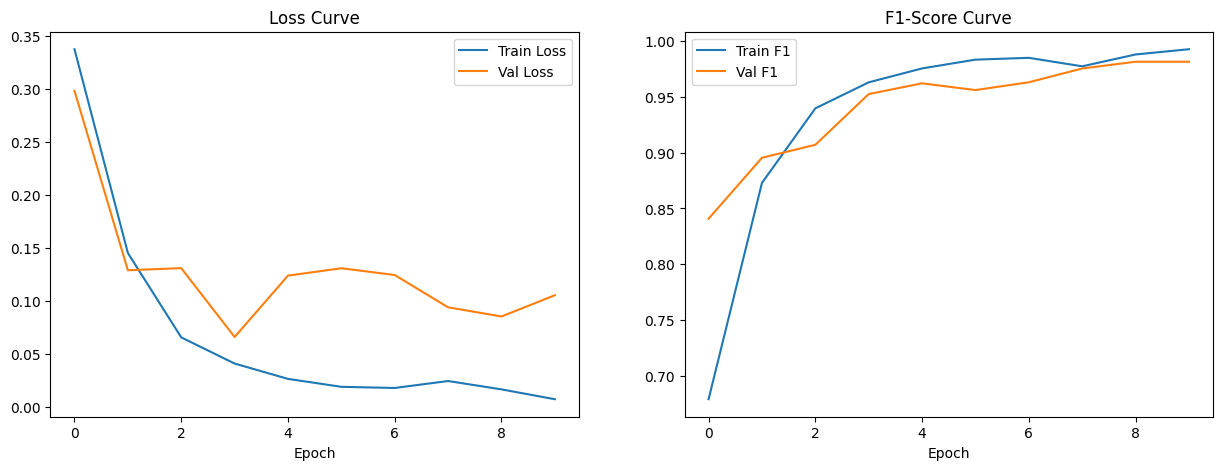

In [ ]:
plt.figure(figsize=(20, 5))

# 1. Vẽ Loss
plt.subplot(1, 3, 1)
plt.plot(history['train_loss'], label='Train Loss')
plt.plot(history['val_loss'], label='Val Loss')
plt.title('Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

# 2. Vẽ F1-Score
plt.subplot(1, 3, 2)
plt.plot(history['train_f1'], label='Train F1')
plt.plot(history['val_f1'], label='Val F1')
plt.title('F1-Score Curve')
plt.xlabel('Epoch')
plt.ylabel('F1-Score')
plt.legend()

# 3. Vẽ Accuracy
plt.subplot(1, 3, 3)
plt.plot(history['train_acc'], label='Train Acc')
plt.plot(history['val_acc'], label='Val Acc')
plt.title('Accuracy Curve')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.tight_layout()
plt.show()

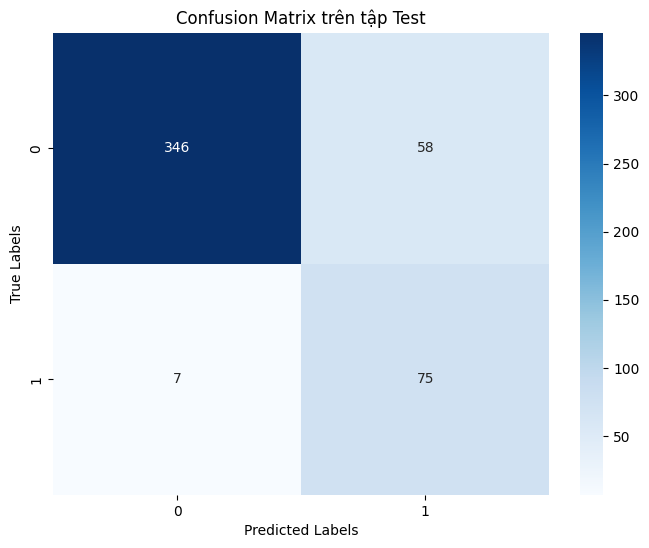

In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Dự đoán trên tập test
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for batch in test_loader:
        # Chuyển dữ liệu sang GPU
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)

        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, preds = torch.max(outputs.logits, 1)

        all_preds.extend(preds.cpu().numpy())
        # Đảm bảo labels được chuyển về định dạng mảng để tính toán
        all_labels.extend(batch['labels'].cpu().numpy())

# Vẽ ma trận
cm = confusion_matrix(all_labels, all_preds)

# Định nghĩa tên nhãn
labels_name = ['Tin thật (0)', 'Tin giả (1)']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels_name,
            yticklabels=labels_name)

plt.title('Confusion Matrix trên tập Test')
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.show()

In [ ]:
import torch
from sklearn.metrics import f1_score
from tqdm import tqdm

def sliding_window(text, window_size=200, overlap=50):
    words = text.split()
    segments = []
    step = window_size - overlap
    for i in range(0, len(words), step):
        segment = " ".join(words[i : i + window_size])
        segments.append(segment)
        if i + window_size >= len(words): break
    return segments

def predict_single_text(raw_text, model, tokenizer, device):
    model.eval()
    encoding = tokenizer(
        raw_text,
        add_special_tokens=True,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )
    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        _, predicted = torch.max(outputs.logits, 1)

    return predicted.item() # Trả về 0 hoặc 1

def predict_long_text_sliding_window(raw_text, model, tokenizer, device, window_size=200, overlap=50):
    words = raw_text.split()
    if len(words) <= window_size:
        return predict_single_text(raw_text, model, tokenizer, device)

    segments = sliding_window(raw_text, window_size, overlap)
    votes = [predict_single_text(seg, model, tokenizer, device) for seg in segments]
    # Voting: Nếu > 50% số đoạn là Tin giả (1) -> Tin giả (1)
    return 1 if sum(votes) / len(votes) > 0.5 else 0

def evaluate_with_sliding_window(df_val, model, tokenizer, device):
    model.eval()
    all_preds = []
    all_labels = df_val['labels'].tolist()

    with torch.no_grad():
        # Dùng tqdm để hiển thị thanh tiến trình
        for _, row in tqdm(df_val.iterrows(), total=len(df_val), desc="Evaluating"):
            pred = predict_long_text_sliding_window(str(row['text']), model, tokenizer, device)
            all_preds.append(pred)

    # Tính F1-score trên toàn bộ dữ liệu đã được quét qua cửa sổ trượt
    f1 = f1_score(all_labels, all_preds, average='binary')
    return 0.0, f1 # Trả về 0.0 cho loss vì sliding window không dùng loss chuẩn của batch


--- ĐANG CHẠY KIỂM TRA TRÊN TẬP TEST ---


Testing: 100%|██████████| 31/31 [00:05<00:00,  5.87it/s]


BÁO CÁO KẾT QUẢ TRÊN TẬP TEST
              precision    recall  f1-score   support

Tin thật (0)       1.00      1.00      1.00       404
 Tin giả (1)       1.00      0.98      0.99        82

    accuracy                           1.00       486
   macro avg       1.00      0.99      0.99       486
weighted avg       1.00      1.00      1.00       486



In [ ]:
# --- 1. ĐỊNH NGHĨA HÀM GỘP XỬ LÝ ---
def preprocess_text(text):
    text = clean_text(text)
    text = segment_text(text)
    # Lưu ý: Nếu muốn dùng Sliding Window hiệu quả, bạn nên bỏ truncate_text tại đây
    # hoặc để nó ở mức cao hơn (ví dụ 500) để không làm mất dữ liệu trước khi cắt window.
    return text

# --- 2. HÀM DỰ ĐOÁN MÔ HÌNH VỚI SLIDING WINDOW ---
def sliding_window(text, window_size, overlap):
    words = text.split()
    segments = []
    step = window_size - overlap
    for i in range(0, len(words), step):
        segment = " ".join(words[i : i + window_size])
        segments.append(segment)
        if i + window_size >= len(words): break
    return segments

def predict_single_text(raw_text, model, tokenizer, device):
    processed_text = preprocess_text(raw_text)

    model.eval()
    encoding = tokenizer(
        processed_text,
        add_special_tokens=True,
        max_length=256,
        padding='max_length',
        truncation=True,
        return_tensors='pt'
    )

    input_ids = encoding['input_ids'].to(device)
    attention_mask = encoding['attention_mask'].to(device)

    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        probs = torch.softmax(outputs.logits, dim=1)
        _, predicted = torch.max(outputs.logits, 1)
        confidence = probs[0][predicted.item()].item()

    label_name = "Tin giả" if predicted.item() == 1 else "Tin thật"
    return label_name, confidence

def predict_long_text_sliding_window(raw_text, model, tokenizer, device, window_size=200, overlap=50):
    words = raw_text.split()
    if len(words) <= window_size:
        return predict_single_text(raw_text, model, tokenizer, device)

    segments = sliding_window(raw_text, window_size=window_size, overlap=overlap)

    decisions = [] # Lưu 0 hoặc 1
    confidences = [] # Lưu xác suất từ mô hình

    for seg in segments:
        label_name, conf = predict_single_text(seg, model, tokenizer, device)
        decisions.append(1 if label_name == "Tin giả" else 0)
        confidences.append(conf)

    final_decision = 1 if sum(decisions) / len(decisions) > 0.5 else 0
    final_label = "Tin giả" if final_decision == 1 else "Tin thật"

    # Tính trung bình độ tự tin của các đoạn
    avg_conf = sum(confidences) / len(confidences)

    return final_label, avg_conf

# --- 3. THỰC HIỆN DỰ ĐOÁN ---
# Đảm bảo đường dẫn file .pth chính xác với máy của bạn
model.load_state_dict(torch.load("best_model_f1.pth", map_location=device))
model.to(device)

# Nhập nội dung cần test
test_input = """Trời ơi tin được không, ăn lá đu đủ có thể chữa khỏi ung thư? Mình đã thử và thấy hiệu quả bất ngờ!
Giá như mà biết sớm hơn thì mình đã không phải chịu đựng hóa trị đau đớn. Mọi người hãy thử ngay đi, rất đơn giản và rẻ tiền mà lại có thể cứu sống được nhiều người!"""

# Gọi hàm dự đoán dùng Sliding Window
result, conf = predict_long_text_sliding_window(test_input, model, tokenizer, device)

print("-" * 40)
print(f"Nội dung: {test_input}")
print(f"Kết quả dự đoán: {result}")
# Nếu kết quả là xác suất, bạn có thể nhân với 100
print(f"Độ tự tin (tỷ lệ đoạn đồng thuận): {conf*100:.2f}%")
print("-" * 40)

----------------------------------------
Nội dung: Trời ơi tin được không, ăn lá đu đủ có thể chữa khỏi ung thư? Mình đã thử và thấy hiệu quả bất ngờ! 
Giá như mà biết sớm hơn thì mình đã không phải chịu đựng hóa trị đau đớn. Mọi người hãy thử ngay đi, rất đơn giản và rẻ tiền mà lại có thể cứu sống được nhiều người!
Kết quả dự đoán: Tin giả
Độ tự tin: 99.89%
----------------------------------------
